# Scottish Election May 2026 polls analysis

## Data Ingestion and software prerequisites

In [1]:
import pandas as pd

Raw data from https://knutley.github.io/STAEM_Project/

In [15]:
constituency_df=(pd
                 .read_csv('constituency.csv',
                           parse_dates=[0],
                           sep='\%?,',
                           engine='python',
                           na_values='—')
                )

In [16]:
regional_df=(pd
             .read_csv('regional_list.csv',
                       parse_dates=[0],
                       sep='\%?,',
                       engine='python',
                       na_values='—')#,
                       #dtype={'Sample':float,'Con':float,'Labour':float,'Lib Dem':float,'SNP':float,'Alba':float,
                       #       'Reform':float,'Green':float})#,'Others':float
            )

In [36]:
party_colours={'Con':'tab:blue',
              'Labour':'tab:red',
              'Lib Dem':'tab:orange',
              'SNP':'y',
              'Alba':'tab:purple',
              'Reform':'tab:cyan',
              'Green':'tab:green'}

## Analysis

### Constituency

<AxesSubplot: xlabel='Date', ylabel='Sample size'>

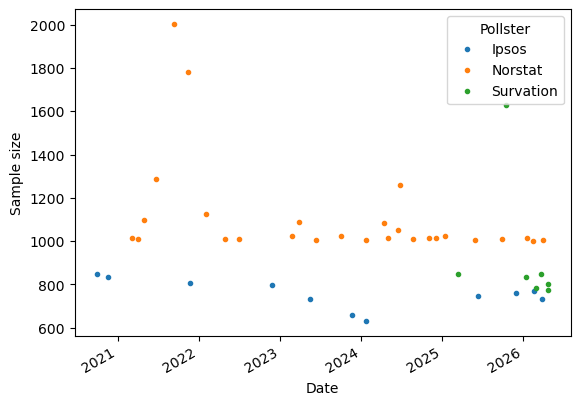

In [37]:
(constituency_df
 .set_index(['Date','Pollster'])
 .unstack()
 .Sample
 #.SNP
 .plot(marker='.',ls='',ylabel='Sample size')#,colors={'Con':'tab10-blue'})
)

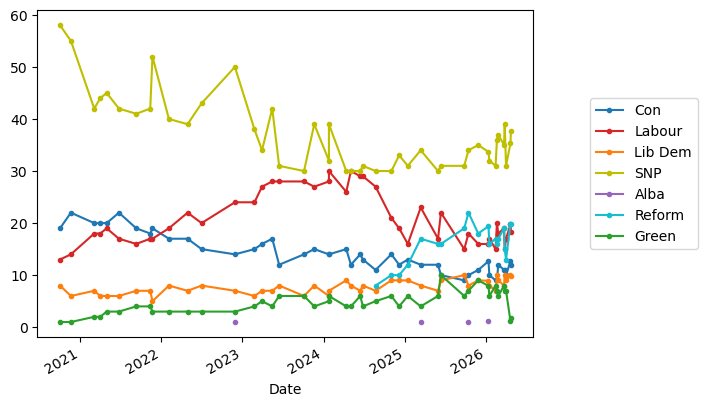

In [39]:
(constituency_df
 .set_index('Date')
 .drop(columns='Sample')
 #.SNP
 .plot(marker='.',color=party_colours)
 .legend(loc='center left',bbox_to_anchor=(1.1, 0.5))
)

Gives the impression that SNP is oscillating up and down

<AxesSubplot: xlabel='Date'>

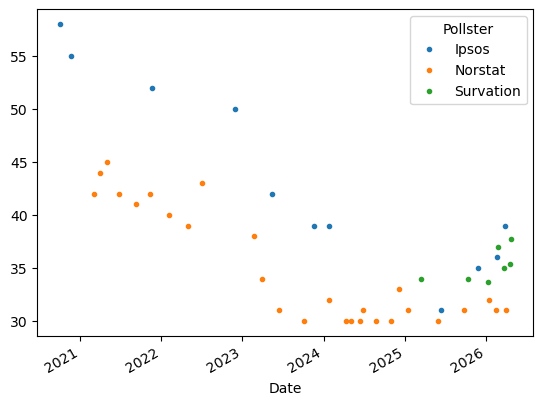

In [40]:
(constituency_df
 [['Date','Pollster','SNP']]
 .pivot(index='Date',columns='Pollster',values='SNP')
 .plot(marker='.',ls='')
)

Ipsos with smaller sample sizes consistently shows SNP high. Norstat with higher sample sizes shows it low in the earlier years of the decade.

<AxesSubplot: xlabel='Date', ylabel='SNP interpolated % constituency vote'>

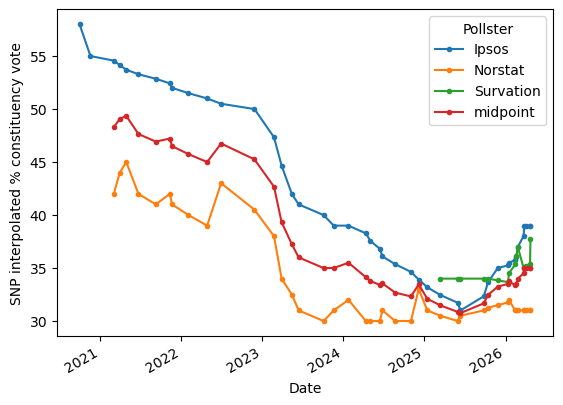

In [41]:
(constituency_df
 [['Date','Pollster','SNP']]
 .pivot(index='Date',columns='Pollster',values='SNP')
 .interpolate()
 .assign(midpoint= lambda df: df[['Ipsos','Norstat']].mean(axis='columns',skipna=False))
 .plot(marker='.',ylabel='SNP interpolated % constituency vote')
)

<AxesSubplot: xlabel='Date'>

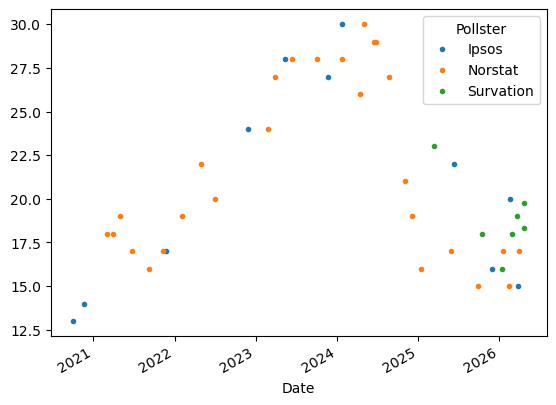

In [42]:
(constituency_df
 [['Date','Pollster','Labour']]
 .pivot(index='Date',columns='Pollster',values='Labour')
 .plot(marker='.',ls='')
)

likewise Labour oscillates between low Norstat and high other in the last couple of years

<AxesSubplot: xlabel='Date', ylabel='Labour interpolated % constituency vote'>

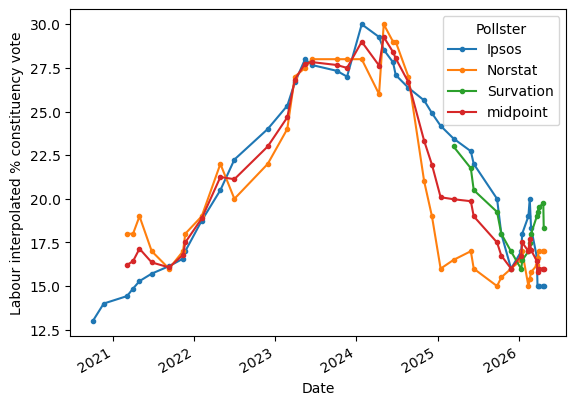

In [43]:
(constituency_df
 [['Date','Pollster','Labour']]
 .pivot(index='Date',columns='Pollster',values='Labour')
 .interpolate()
 .assign(midpoint= lambda df: df[['Ipsos','Norstat']].mean(axis='columns',skipna=False))
 .plot(marker='.',ylabel='Labour interpolated % constituency vote')
)

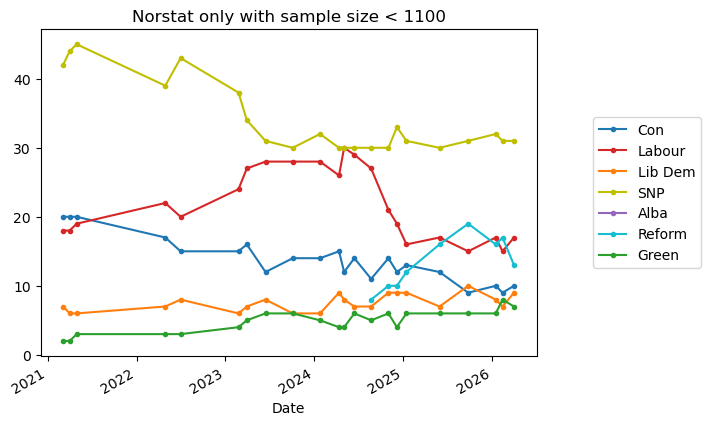

In [49]:
(constituency_df
 .query('Pollster=="Norstat" and Sample<1100')
 .set_index('Date')
 .drop(columns='Sample')
 #.SNP
 .plot(marker='.',title="Norstat only with sample size < 1100",color=party_colours)
 .legend(loc='center left',bbox_to_anchor=(1.1, 0.5))
)

### regional

In [45]:
regional_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      95 non-null     datetime64[ns]
 1   Pollster  95 non-null     object        
 2   Client    95 non-null     object        
 3   Sample    95 non-null     int64         
 4   Con       85 non-null     float64       
 5   Labour    84 non-null     float64       
 6   Lib Dem   85 non-null     float64       
 7   SNP       85 non-null     float64       
 8   Alba      53 non-null     float64       
 9   Reform    55 non-null     float64       
 10  Green     85 non-null     float64       
 11  Others    73 non-null     object        
dtypes: datetime64[ns](1), float64(7), int64(1), object(3)
memory usage: 9.0+ KB


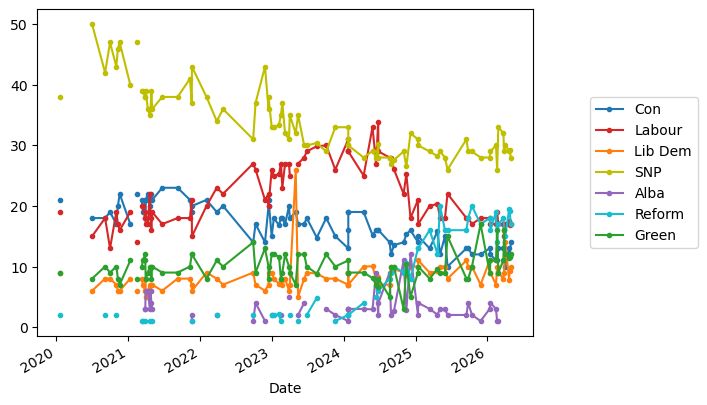

In [46]:
(regional_df
 .set_index(['Date'])
 .sort_index()
 .drop(columns='Sample')
 .loc['2016':]
 .plot(marker='.',color=party_colours)
 .legend(loc='center left',bbox_to_anchor=(1.1, 0.5))
)

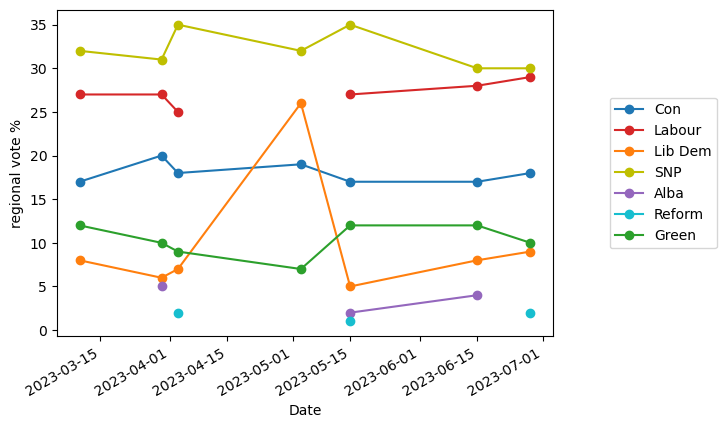

In [47]:
(regional_df
 .set_index(['Date'])
 .sort_index()
 .drop(columns='Sample')
 .loc['2023-03':'2023-06']
 .plot(marker='o',ylabel='regional vote %',color=party_colours)
 .legend(loc='center left',bbox_to_anchor=(1.1, 0.5))
)

In [48]:
(regional_df
 .set_index(['Date'])
 .sort_index()
 .loc['2023-03':'2023-06']
)

,Pollster,Client,Sample,Con,Labour,Lib Dem,SNP,Alba,Reform,Green,Others
Date,,,,,,,,,,,
2023-03-10,Norstat,Norstat,1013,17.0,27.0,8.0,32.0,NaN,NaN,12.0,3%
2023-03-30,Norstat,Norstat,1089,20.0,27.0,6.0,31.0,5.0,NaN,10.0,2%
2023-04-03,Survation,Survation,844,18.0,25.0,7.0,35.0,NaN,2.0,9.0,2%
2023-05-03,Survation,Survation,838,19.0,NaN,26.0,32.0,NaN,NaN,7.0,2%
2023-05-15,Ipsos,IPSOS,735,17.0,27.0,5.0,35.0,2.0,1.0,12.0,1%
2023-06-15,Norstat,Norstat,1007,17.0,28.0,8.0,30.0,4.0,NaN,12.0,1%
2023-06-28,Survation,Survation,1623,18.0,29.0,9.0,30.0,NaN,2.0,10.0,2%


26% makes no sense for the Lib Dems. Was it a labour percentage that was given to Lib Dems by mistake?